# BrushCue Example: 2010s Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/2010s_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/2010s-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


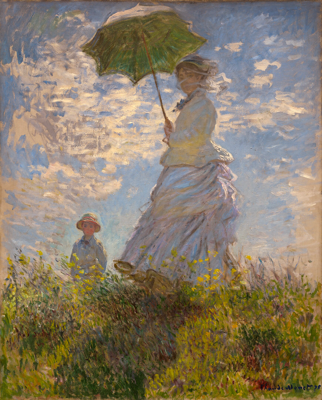

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
graded = (
    input_image.r_g_b_curve(
        bc.Curve.gamma(0.95), bc.Curve.gamma(0.99), bc.Curve.gamma(1.04)
    )
    .l_curve(bc.Curve.pivoted_sigmoid(0.52, 0.8))
    .saturation_adjust(1.03)
    .chroma_offset(bc.Vector2f.from_components(0.018, 0.02))
)
bounds = input_image.bounds()
filtered = graded.vignette(
    bc.Vector2f.from_components((bounds.width() / 2.0), (bounds.height() / 2.0)),
    (bounds.width() / 2.0),
    (bounds.height() / 2.0),
    350.0,
    0.18,
).crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
